In [ ]:
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np

In [3]:
wine_data = pd.read_csv('../winequality-white.csv', sep=';')
wine_feat = wine_data.iloc[:, :-1]
wine_target = wine_data.iloc[:, -1]

In [4]:
wine_target

0       6
1       6
2       6
3       6
4       6
       ..
4893    6
4894    5
4895    6
4896    7
4897    6
Name: quality, Length: 4898, dtype: int64

## Descrição preliminar dos dados

O conjunto de dados consiste em **N = 4897** amostras do vinho branco português, chamado "Vinho Verde". A fonte original do dataset inclui amostras de vinhos branco e vermelho, entretanto, como essa variação de tipo pode afetar nos gostos e, portanto, nos resultados preditos, optamos por limitar para aquele do qual temos mais amostras, a saber, o vinho branco. Para a garantia de qualidade e segurança da saúde humana, a indústria de vinhos submete seus produtos a testes fisicoquímicos em laboratório, incluindo a medição de valores como pH ou densidade da bebida, além dos valores melhor detalhados abaixo.

O dataset contém as seguintes informações:
-  Fixed acidity: Concentração de ácido tártaro (g/dm³)
-  Volatile acidity: Concentração de ácido acético (g/dm³)
-  Citric acid: Concentração de ácido cítrico (g/dm³)
-  Residual sugar: Concentração de açúcar residual (g/dm³)
-  Chlorides: Concentração de cloreto de sódio (g/dm³)
-  Free sulfur dioxide: Concentração de dióxido de enxofre livre (mg/dm³)
-  Total sulfur dioxide: Concentração total de dióxido de enxofre (mg/dm³)
-  Density: Densidade do vinho (g/dm³)
-  pH
-  Sulphates: Concentração de sulfato de potássio (g/dm³)
-  Alcohol: Volume de álcool (vol.%)
-  Quality: Qualidade do vinho (classificação inteira entre 0 e 10)

Realizando uma simples análise do conjunto de dados, considerando que desejamos inferir a qualidade de um certo vinho dadas as suas medições laboratoriais, temos que o dataset possui **D = 11** variáveis preditoras, a saber, medições químicas de laboratório, e **L = 11** classes, que são as diferentes classificações do vinho quanto à sua qualidade, que pode variar entre 0 e 10. Posteriormente, analisaremos a distribuição entre classes.

In [5]:
N = wine_data.shape[0]
D = wine_feat.shape[1]
L = 11

<Axes: title={'center': 'Distribuição de classes de vinho branco'}, xlabel='Qualidade do vinho', ylabel='Número de amostras'>

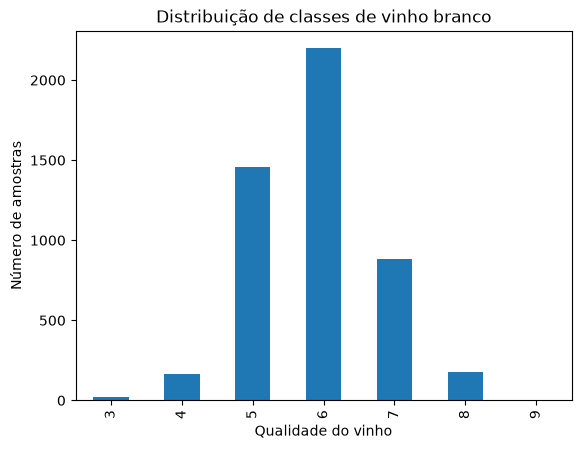

In [6]:
class_distrib = wine_target.value_counts()
class_distrib
class_distrib.sort_index(inplace=True)
class_distrib.plot(kind='bar', title='Distribuição de classes de vinho branco', xlabel='Qualidade do vinho', ylabel='Número de amostras')

Vemos, no resultado acima, uma distribuição equilibrada entre as classes de vinho, concentrando-se em valores médios, enquanto valores extremos (baixos e altos) são escassos. Nota-se que essa distribuição aproxima-se de uma distribuição normal.

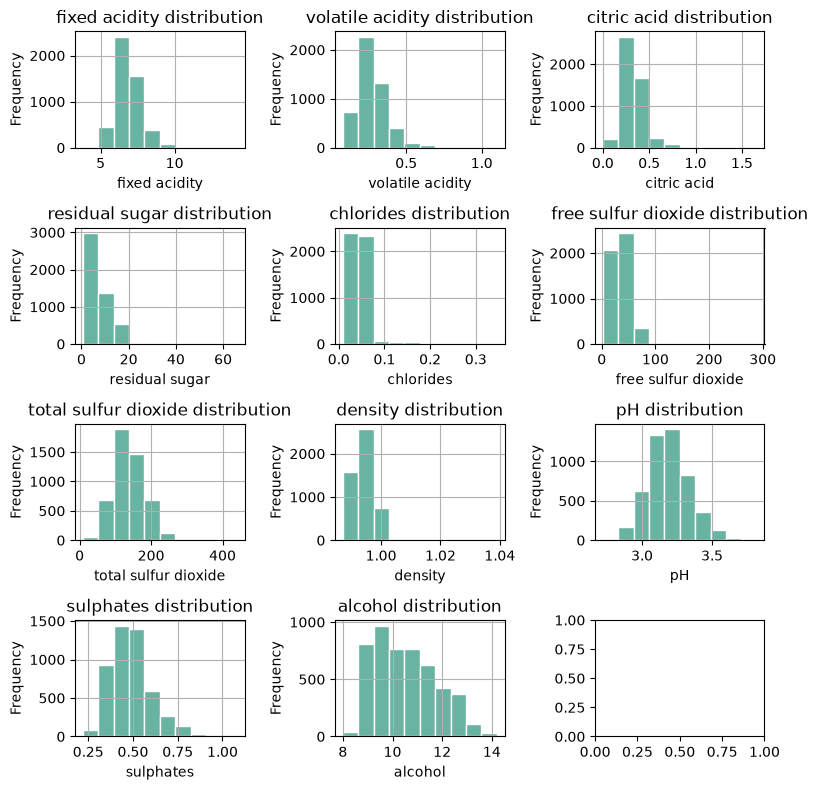

In [7]:
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(8, 8))

# Flatten the axes array (makes it easier to iterate over)
axes = axes.flatten()

# Loop through each column and plot a histogram
for i, column in enumerate(wine_feat.columns):
    
    # Add the histogram
    wine_feat[column].hist(ax=axes[i], # Define on which ax we're working on
                    edgecolor='white', # Color of the border
                    color='#69b3a2' # Color of the bins
                   )
    
    # Add title and axis label
    axes[i].set_title(f'{column} distribution') 
    axes[i].set_xlabel(column) 
    axes[i].set_ylabel('Frequency') 

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

## Os gráficos abaixo são para visualização da equipe, devendo ser filtrados para o que vamos colocar no artigo.

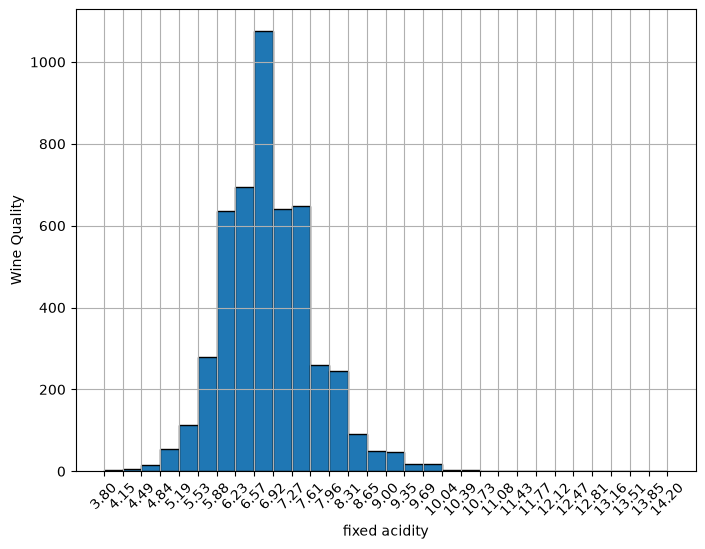

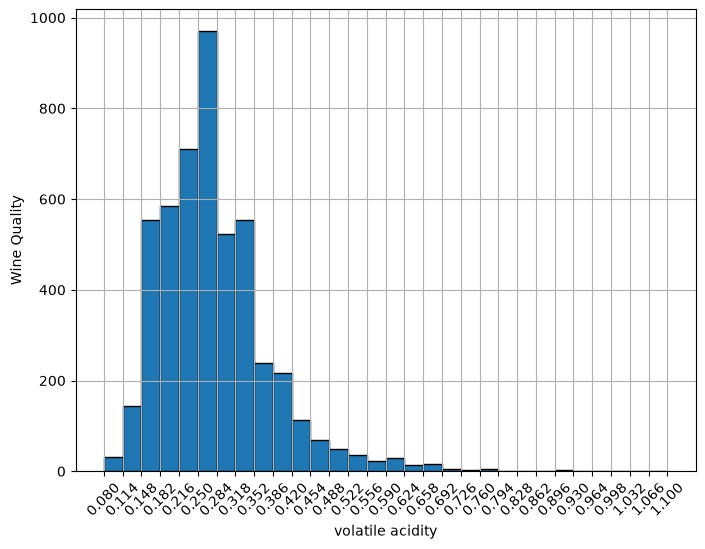

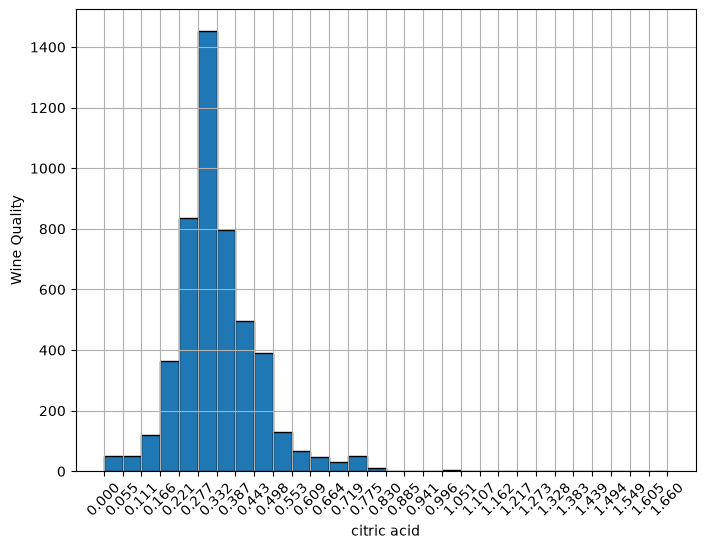

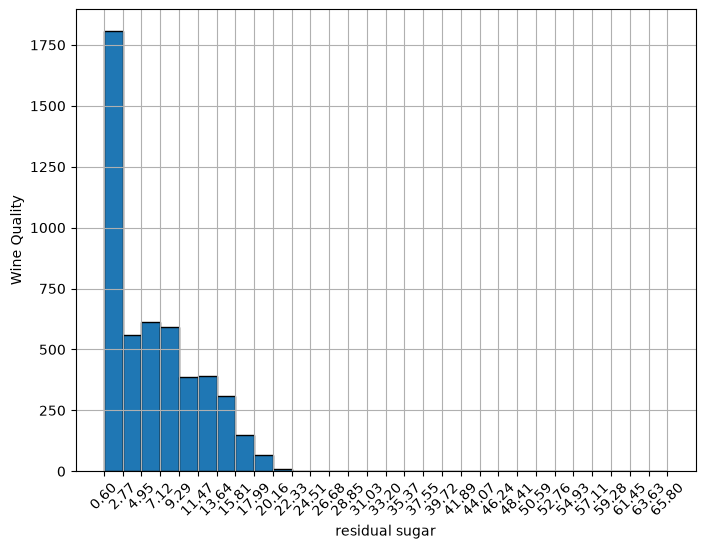

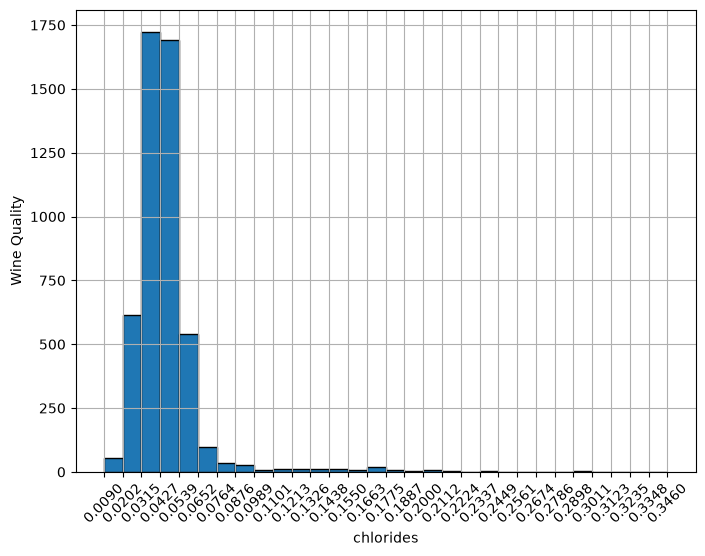

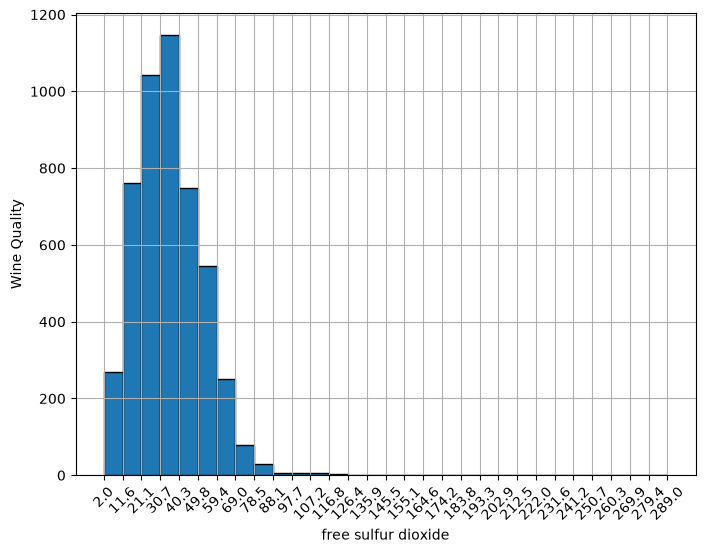

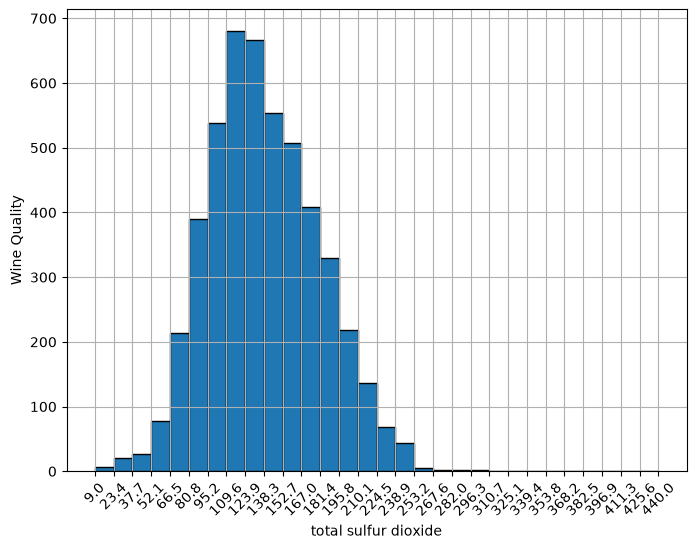

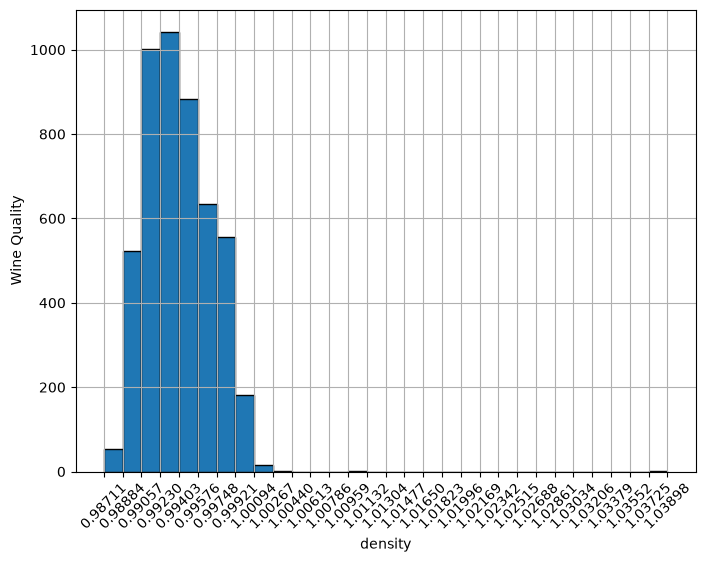

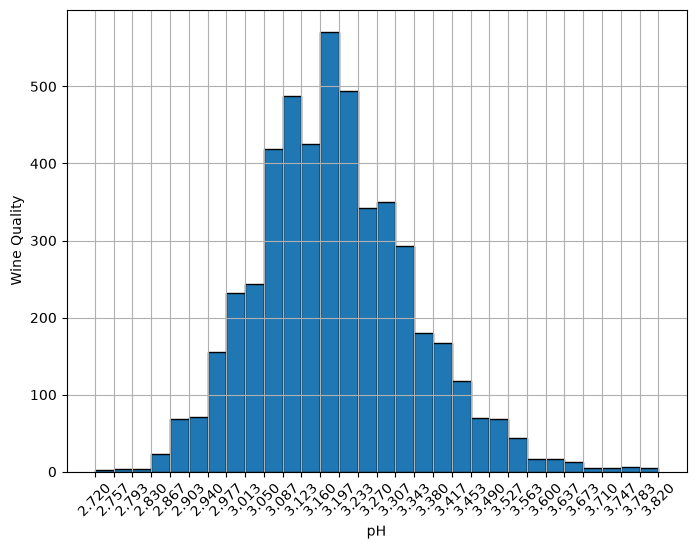

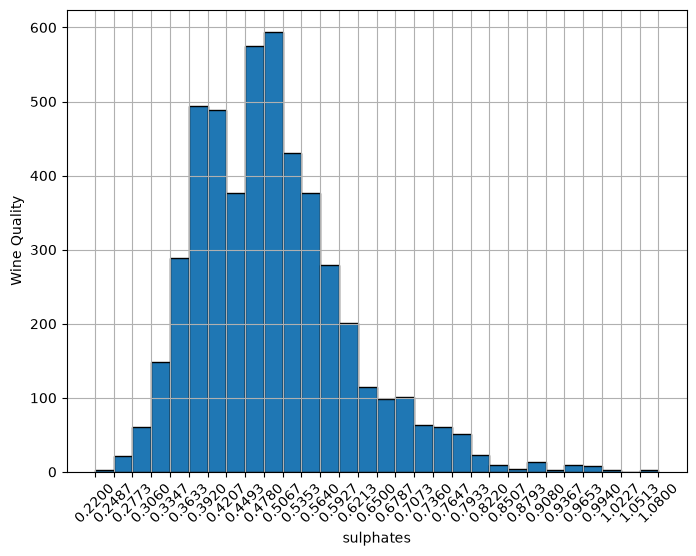

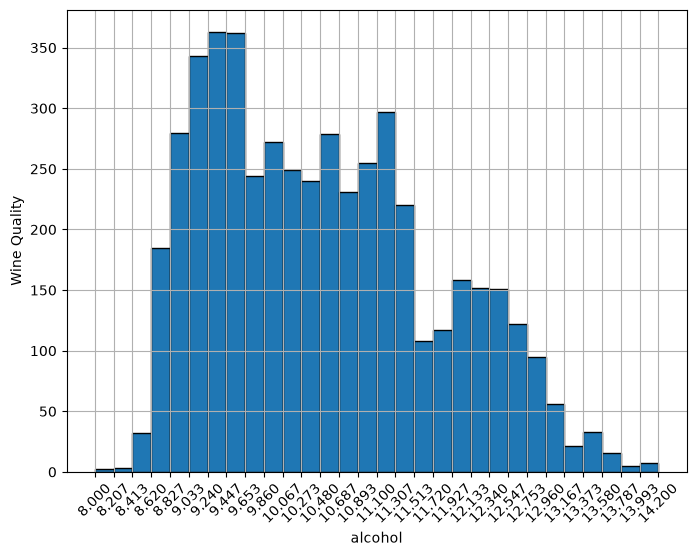

In [17]:
for col in wine_feat.columns:
    plt.figure(figsize=(8, 6))
    n, bins, patches = plt.hist(wine_feat[col], bins=30, edgecolor='black')
    plt.xlabel(col)
    plt.ylabel('Wine Quality')
    plt.xticks(bins,
               rotation=45)
    plt.grid()
    plt.show()

## Os gráficos abaixo são para visualização da equipe, devendo ser filtrados para o que vamos colocar no artigo.

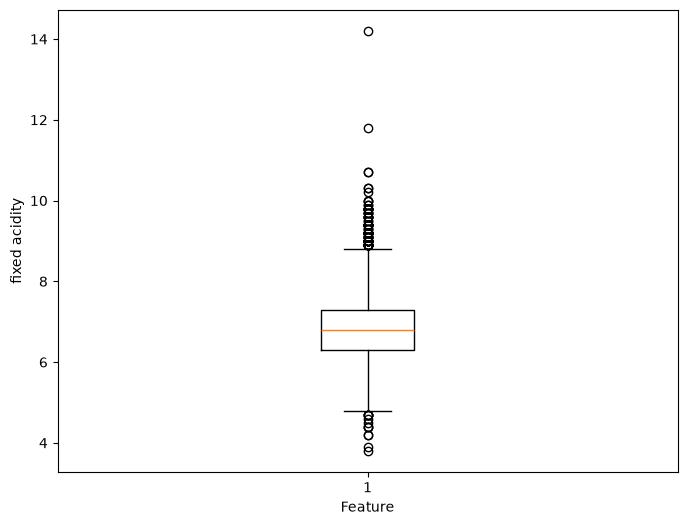

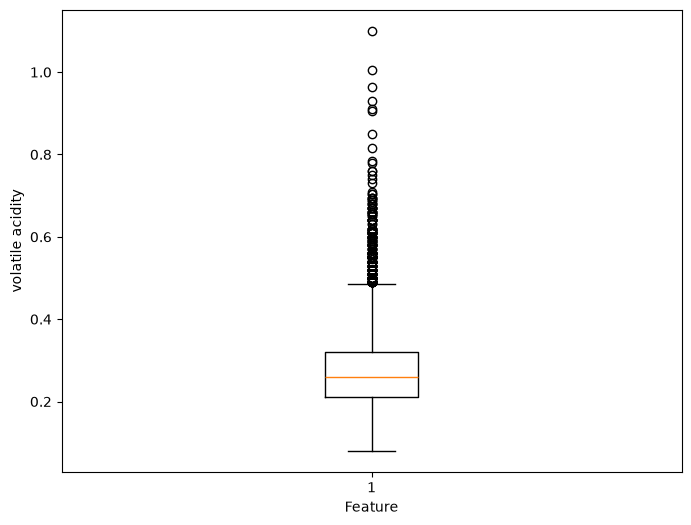

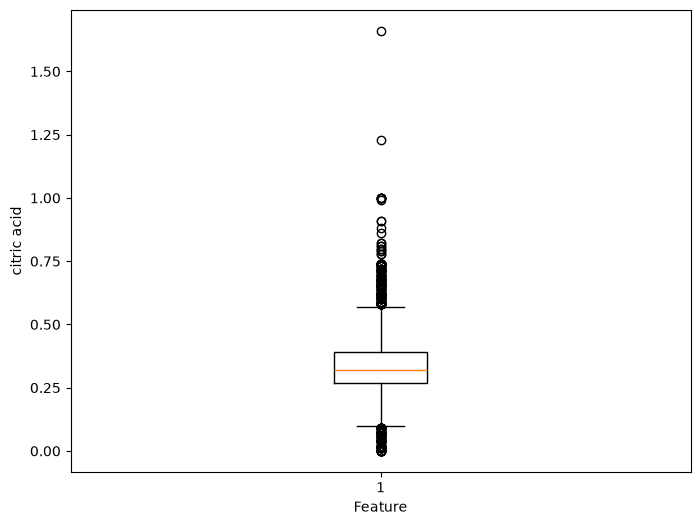

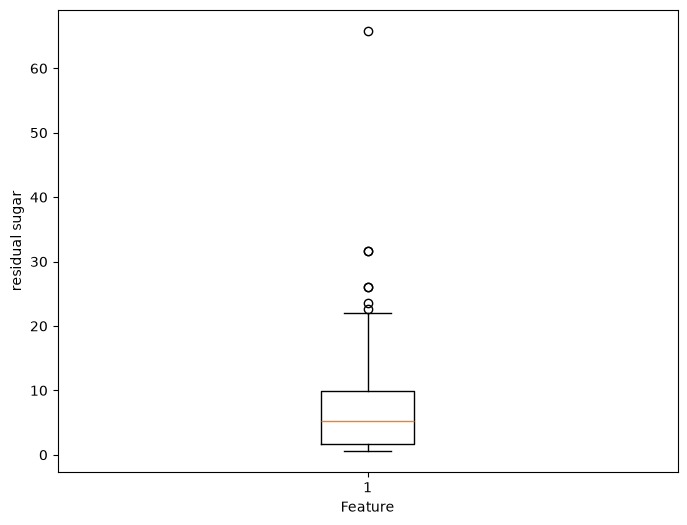

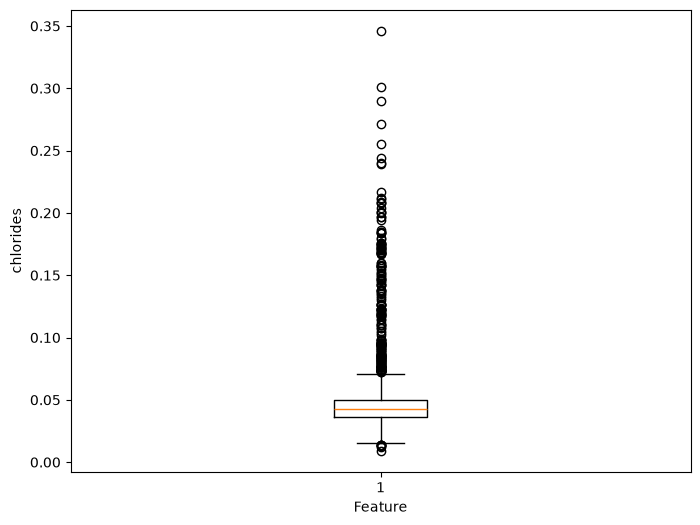

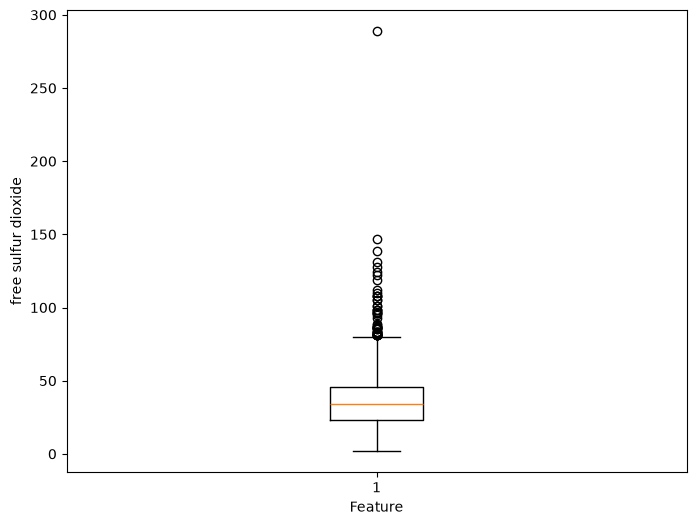

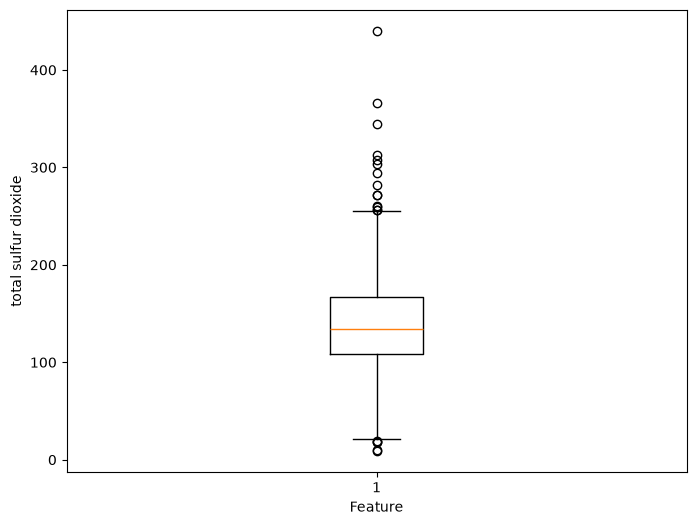

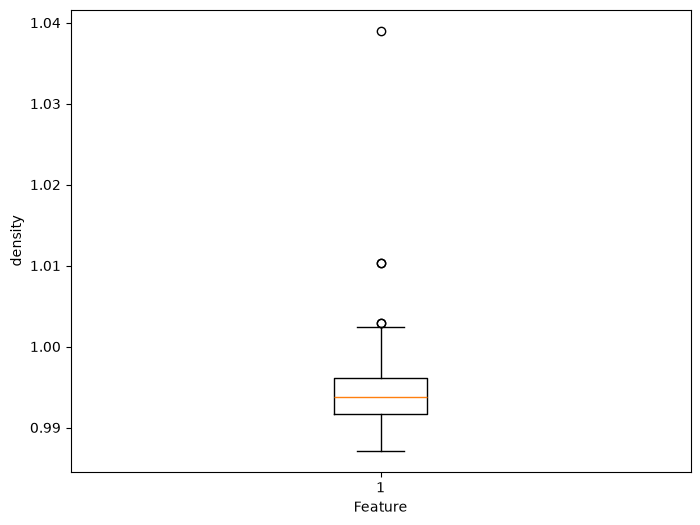

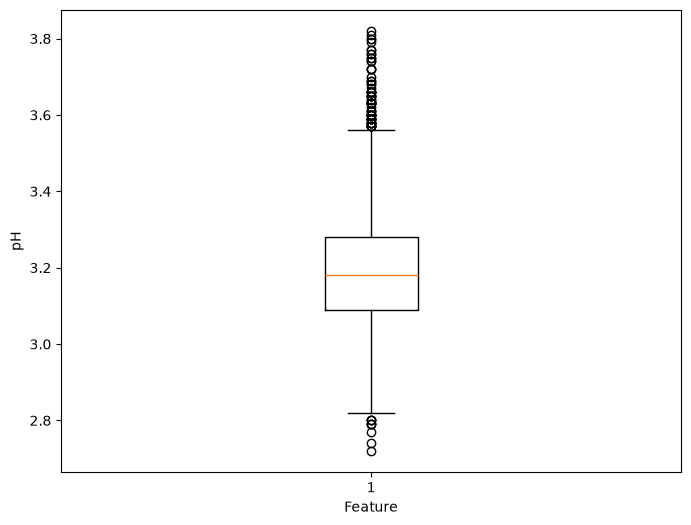

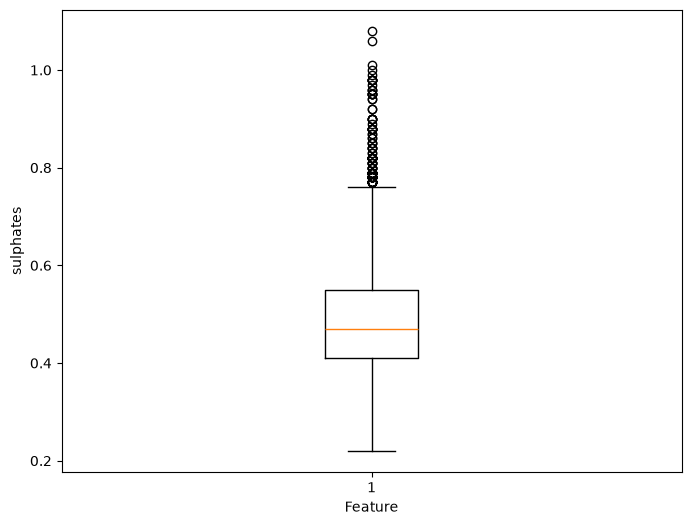

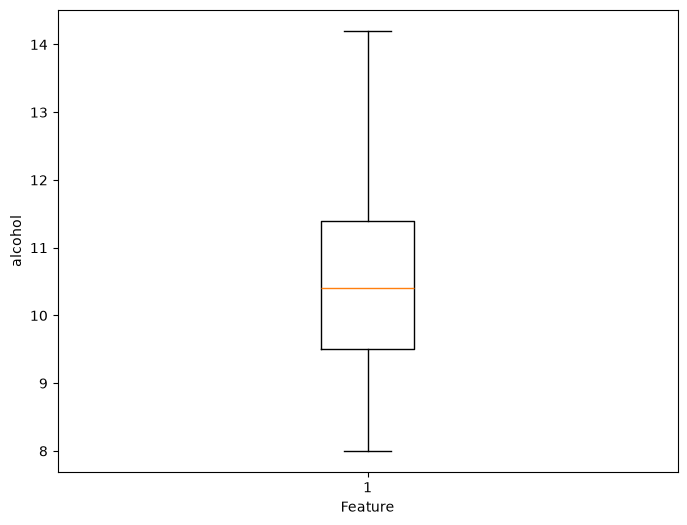

In [13]:
for col in wine_feat.columns:
    plt.figure(figsize=(8, 6))
    plt.boxplot(wine_feat[col])
    plt.ylabel(col)
    plt.xlabel('Feature')
    plt.show()

### Valores incondicionais

In [18]:
for col in wine_feat.columns:
    print(f"Média de {col}: {wine_feat[col].mean()}")

Média de fixed acidity: 6.854787668436097
Média de volatile acidity: 0.27824111882400976
Média de citric acid: 0.33419150673744386
Média de residual sugar: 6.391414863209474
Média de chlorides: 0.04577235606369946
Média de free sulfur dioxide: 35.30808493262556
Média de total sulfur dioxide: 138.36065741118824
Média de density: 0.9940273764801959
Média de pH: 3.1882666394446715
Média de sulphates: 0.48984687627603113
Média de alcohol: 10.514267047774602


In [19]:
for col in wine_feat.columns:
    print(f"Desvio padrão de {col}: {wine_feat[col].std()}")

Desvio padrão de fixed acidity: 0.843868227687513
Desvio padrão de volatile acidity: 0.10079454842486534
Desvio padrão de citric acid: 0.12101980420298249
Desvio padrão de residual sugar: 5.072057784014881
Desvio padrão de chlorides: 0.021847968093728798
Desvio padrão de free sulfur dioxide: 17.00713732523259
Desvio padrão de total sulfur dioxide: 42.49806455414291
Desvio padrão de density: 0.0029909069169369337
Desvio padrão de pH: 0.1510005996150668
Desvio padrão de sulphates: 0.1141258339488323
Desvio padrão de alcohol: 1.230620567757318


In [ ]:
for col in wine_feat.columns:
    print(f"skewness de {col}: {wine_feat[col].skew()}")

skewness de fixed acidity: 0.6477514746297539
skewness de volatile acidity: 1.5769795029952025
skewness de citric acid: 1.2819203981671066
skewness de residual sugar: 1.0770937564240868
skewness de chlorides: 5.023330682759711
skewness de free sulfur dioxide: 1.4067449205303078
skewness de total sulfur dioxide: 0.3907098416536745
skewness de density: 0.9777730048689898
skewness de pH: 0.4577825459180807
skewness de sulphates: 0.9771936833065663
skewness de alcohol: 0.4873419932161276


In [ ]:
# Juntando features e target para o agrupamento por classe (l)
df_item3 = wine_feat.copy()
df_item3['quality'] = wine_target

# Calculando D x L valores para média, desvio padrão e assimetria
cond_mean = df_item3.groupby('quality').mean()
cond_std = df_item3.groupby('quality').std()
cond_skew = df_item3.groupby('quality').apply(lambda x: x.iloc[:, :-1].skew())

print('Tabela de Médias Condicionais')
display(cond_mean)

print('\nTabela de Desvios Padrão Condicionais')
display(cond_std)

print('\nTabela de Assimetrias Condicionais')
display(cond_skew)

In [ ]:
for l in sorted(wine_target.unique()):
  # Filtra as features apenas para a classe atual
  wine_feat_l = wine_feat[wine_target == l]

  fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(10, 10))

  # Flatten the axes array (makes it easier to iterate over)
  axes = axes.flatten()

  # Loop through each column and plot a histogram
  for i, column in enumerate(wine_feat.columns):
    if i < len(axes):
      # Add the histogram para a classe l
      wine_feat_l[column].hist(
          ax=axes[i],  # Define on which ax we're working on
          edgecolor='white',  # Color of the border
          color='#69b3a2',  # Color of the bins
      )

      # Add title and axis label
      axes[i].set_title(f'{column} (Classe {l})')
      axes[i].set_xlabel(column)
      axes[i].set_ylabel('Frequency')

  # Remove subplots vazios caso a grade seja maior que o número de colunas
  for j in range(len(wine_feat.columns), len(axes)):
    fig.delaxes(axes[j])

  # Adjust layout
  plt.suptitle(f'Class-conditional histograms for Quality = {l}', y=0.98)
  plt.tight_layout()

  # Show the plot
  plt.show()

In [ ]:
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(12, 12))

# Flatten the axes array (makes it easier to iterate over)
axes = axes.flatten()

# Loop through each column and plot a box-plot grouped by quality
for i, column in enumerate(wine_feat.columns):
  if i < len(axes):
    # Add the box-plot grouped by the target class
    wine_data.boxplot(
        column=column,
        by='quality',
        ax=axes[i],  # Define on which ax we're working on
        grid=False,
    )

    # Add title and axis label
    axes[i].set_title(f'{column} by Quality')
    axes[i].set_xlabel('Quality (Class l)')
    axes[i].set_ylabel(column)

# Remove the automatic suptitle generated by pandas boxplot
plt.suptitle('')

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()